✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/inflation_trend_line_plot.png
✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/inflation_trend_box_plot.png
         date  yoy_inflation_pct
60 2024-01-01              29.90
61 2024-02-01              31.70
67 2024-08-01              32.15
68 2024-09-01              32.70
62 2024-03-01              33.20
66 2024-07-01              33.40
63 2024-04-01              33.69
69 2024-10-01              33.88
64 2024-05-01              33.95
65 2024-06-01              34.19
70 2024-11-01              34.60
71 2024-12-01              34.80


<Figure size 1000x500 with 0 Axes>

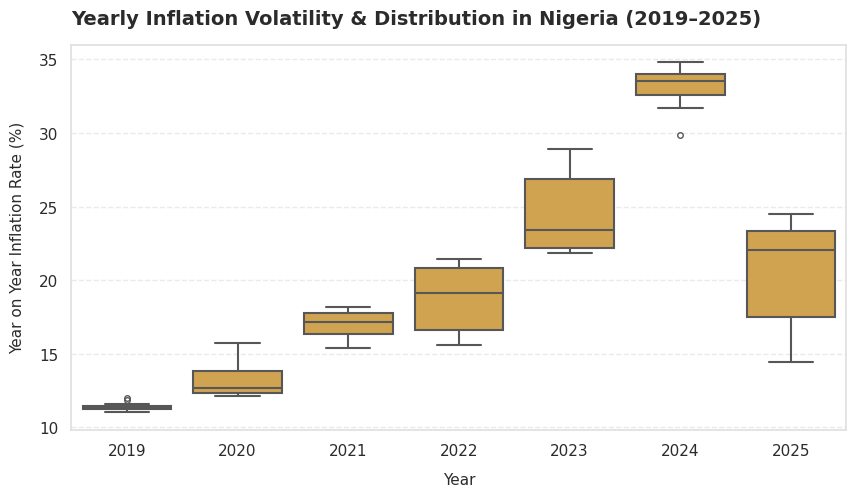

In [ ]:

# 1. How has inflation evolved in Nigeria from 2019 to 2025
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys


PROJECT_ROOT = Path().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, NG_DARK, NG_GREEN, NG_GOLD
from src.utils.saveFigure import saveFigure
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': NG_DARK,
    'axes.labelcolor': NG_DARK,
    'xtick.color': NG_DARK,
    'ytick.color': NG_DARK,
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#EAEAEA',
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})
    
    


# load clean csv
df = pd.read_csv(PROCESSED_DATA_DIR / 'inflation_in_nigeria_2019_2025_clean.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year


# 1. How has inflation evolved in Nigeria from 2019 to 2025?
"""
    First i group the data by year, and take the min, max, mean and std of each column, this is to show the lowest and highest points
    of inflation each year, the average inflation rate and the volatility of inflation each year
"""

inflation_range = (
    df.groupby(df['date'].dt.year)['yoy_inflation_pct']
    .agg(['mean', 'min', 'max', 'std']) 
)
# save figure 
fig1 = plt.figure(figsize=(10, 5))

sns.lineplot(
    data=inflation_range,
    x=inflation_range.index,
    y='mean',
    color=NG_GREEN,
    marker='o',
    linewidth=3,
    markersize=8,
    markerfacecolor=NG_GOLD, 
    markeredgecolor=NG_GREEN
)

plt.title("Inflation Trend in Nigeria (2019–2025)", fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")

saveFigure('inflation_trend_line_plot.png', fig=fig1)

# ____ Plot the volatility by year
plt.clf()
fig2 = plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='year',
    y='yoy_inflation_pct',
    color=NG_GOLD,        
    linewidth=1.5,
    fliersize=4              
)


plt.title("Yearly Inflation Volatility & Distribution in Nigeria (2019–2025)", 
          fontsize=14, fontweight='bold', pad=15, loc='left')
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Year on Year Inflation Rate (%)", fontsize=11, labelpad=10)
saveFigure('inflation_trend_box_plot.png', fig=fig2)

# 1. Use df (the original monthly data), filter for 2024, and sort from lowest to highest
outlier_hunter = df[df['date'].dt.year == 2024].sort_values(by='yoy_inflation_pct')


# 2. Print out the date and the inflation values to locate that ~15.5% outlier
print(outlier_hunter[['date', 'yoy_inflation_pct']])



✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/total-cpi-change-by-category.png


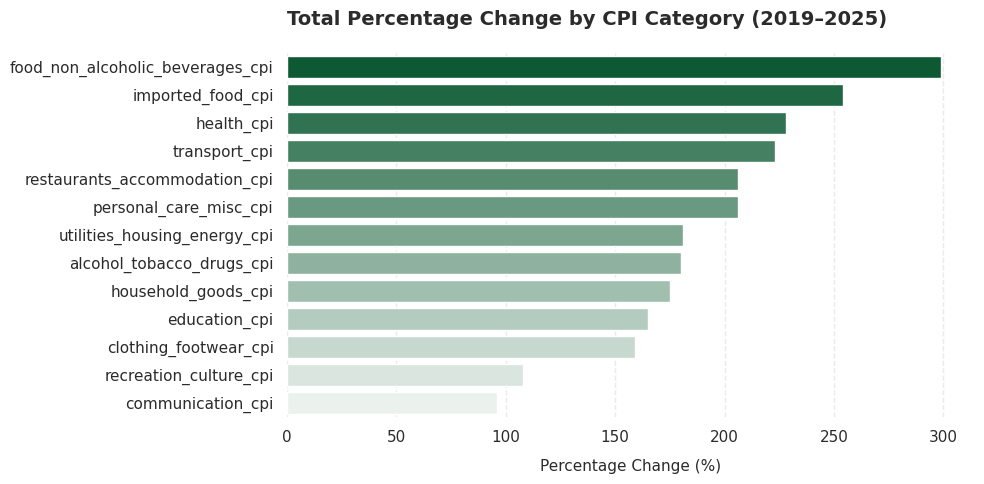

✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/top_5_cpi_growth.png


<Figure size 640x480 with 0 Axes>

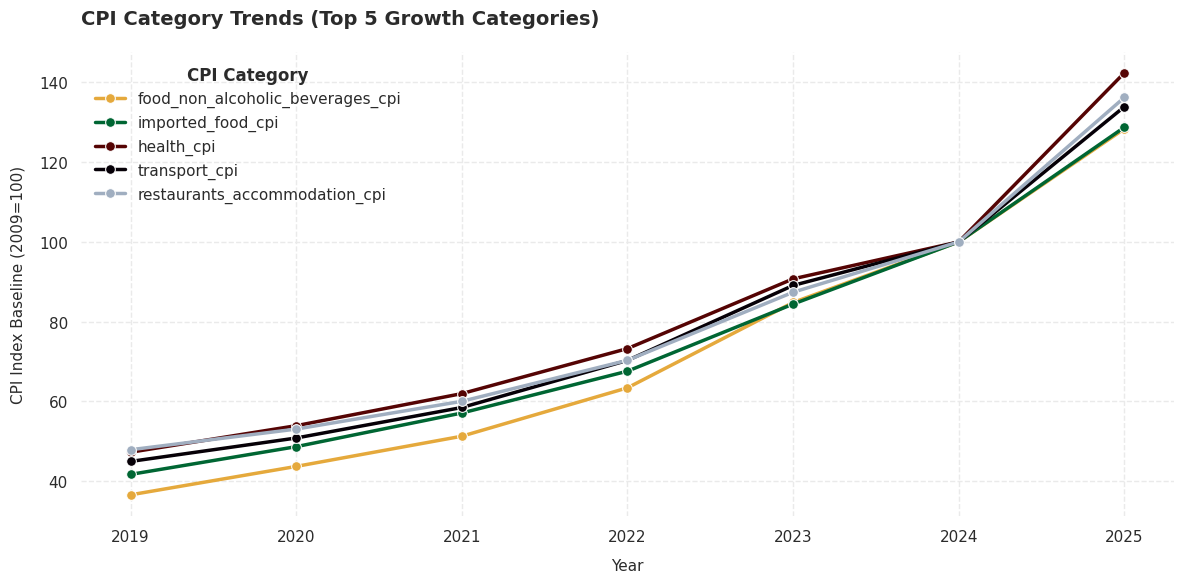

<Figure size 640x480 with 0 Axes>

In [10]:
# 2. Which CPI categories experienced the highest inflation growth?
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd

from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
    
from src.config import PROCESSED_DATA_DIR, NG_DARK, NG_GREEN, NG_GOLD
from src.utils.saveFigure import saveFigure


# =========================================================
# 2. Which CPI categories experienced the highest inflation growth?
# =========================================================

# --- A: Calculate Overall Change ---
cpis_mask = df.columns.str.contains('cpi')
cpi_cols = list(df.columns[cpis_mask])
cols_to_remove = {'overall_cpi', 'core_cpi_ex_food', 'core_cpi_ex_food_energy', 'food_cpi'}
cpi_cols = [item for item in cpi_cols if item not in cols_to_remove]

first_row = df[cpi_cols].iloc[0]
last_row = df[cpi_cols].iloc[-1]
overall_change = (((last_row - first_row) / first_row) * 100).round()
overall_change = overall_change.sort_values(ascending=False)

# =========================================================
# PLOT 1: Branded Bar Chart
# =========================================================
fig1 = plt.figure(figsize=(10, 5))

# Create a clean, professional gradient fading down from your brand green
brand_gradient = sns.light_palette(NG_GREEN, n_colors=len(overall_change), reverse=True)

sns.barplot(
    x=overall_change.values, 
    y=overall_change.index, 
    hue=overall_change.index,  # Keeps modern Seaborn happy
    palette=brand_gradient,
    legend=False
)

# Apply consistent left-aligned brand typography
plt.title("Total Percentage Change by CPI Category (2019–2025)", 
          fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel("Percentage Change (%)", fontsize=11, labelpad=10)
plt.ylabel("", fontsize=11)  # Clear the redundant label since categories are explicit

# Strip the unnecessary spine borders to match previous charts
sns.despine(left=True, bottom=True)

plt.tight_layout()
saveFigure("total-cpi-change-by-category.png", fig=fig1)
plt.show()
plt.clf()


# =========================================================
# PLOT 2: Top 5 Categories Line Chart (Polished)
# =========================================================
top_5 = overall_change.head(5).index.tolist()
annual_top5 = df[top_5].resample("YE").last()
annual_top5 = annual_top5.reset_index()
annual_top5["year"] = annual_top5["date"].dt.year

annual_melted = annual_top5.melt(
    id_vars="year",
    value_vars=top_5,
    var_name="category",
    value_name="cpi_index"
)

fig2 = plt.figure(figsize=(12, 6))

# Define a deliberate brand palette: Highlight the #1 growth driver with Gold,
# use your primary Green for #2, and clean tonal neutrals for the rest.
top5_brand_palette = {
    top_5[0]: NG_GOLD,       # Food & Non-Alcoholic (Highlighted)
    top_5[1]: NG_GREEN,      # Imported Food
    top_5[2]: "#550404",      # Slate Dark
    top_5[3]: "#060007",      # Slate Medium
    top_5[4]: '#A0AEC0'       # Slate Light
}

sns.lineplot(
    data=annual_melted,
    x="year",
    y="cpi_index",
    hue="category",
    palette=top5_brand_palette,
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Apply standard, left-aligned template and design accents
plt.title("CPI Category Trends (Top 5 Growth Categories)", 
          fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("CPI Index Baseline (2009=100)", fontsize=11, labelpad=10)

# Clean, airy legend placement without background boxes
plt.legend(
    title="CPI Category", 
    title_fontproperties={'weight': 'bold'},
    frameon=False, 
    loc="upper left"
)

# Erase structural outer boundaries
sns.despine(left=True, bottom=True)

plt.tight_layout()
saveFigure('top_5_cpi_growth.png', fig=fig2)
plt.show()
plt.clf()

✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/inflation_subsidy_impact_trend.png


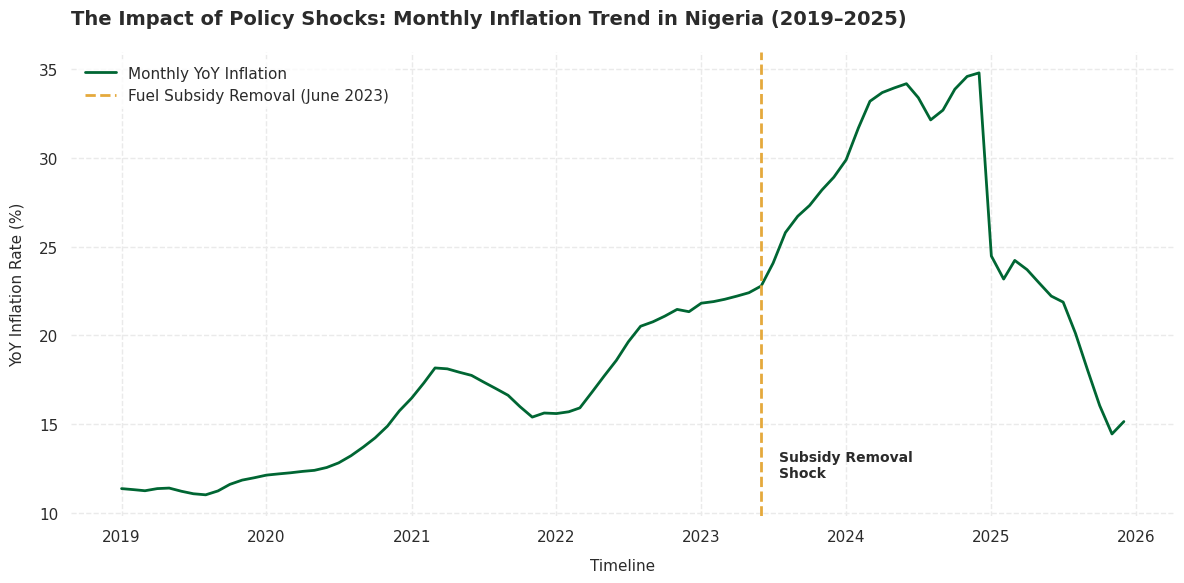

✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/subsidy_era_comparison_bar_chart.png


<Figure size 640x480 with 0 Axes>

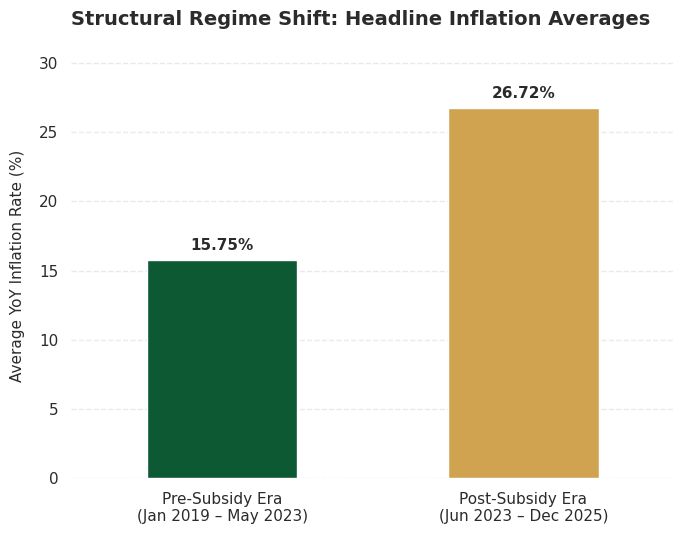

⚡ MOST VOLATILE CPI SECTORS (Ranked by Month-on-Month Standard Deviation):
restaurants_accommodation_cpi       2.34
imported_food_cpi                   2.26
alcohol_tobacco_drugs_cpi           2.21
utilities_housing_energy_cpi        2.13
transport_cpi                       2.11
food_non_alcoholic_beverages_cpi    2.11
clothing_footwear_cpi               2.01
personal_care_misc_cpi              1.89
household_goods_cpi                 1.85
health_cpi                          1.83
education_cpi                       1.79
communication_cpi                   1.09
recreation_culture_cpi              0.97
dtype: float64


<Figure size 640x480 with 0 Axes>

In [11]:
# 3. Did fuel subsidy removal significantly accelerate inflation?
# select from january 2019 to may 2023 as pre subsidy era and from june 2023 upwards as subsidy era


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pre_subsidy = df.loc['2019-01-01':'2023-05-01']
post_subsidy = df.loc['2023-06-01':]




# 1. Create a fresh figure canvas
fig3 = plt.figure(figsize=(12, 6))

# 2. Plot the raw monthly timeline
sns.lineplot(
    data=df,
    x=df.index,              # Uses your date index automatically
    y='yoy_inflation_pct',
    color=NG_GREEN,          # Your branded Nigerian green
    linewidth=2,
    label='Monthly YoY Inflation'
)

# ------------------------------------------------------------------
# ADD THE SUBSIDY REMOVAL MARKER
# ------------------------------------------------------------------
# plt.axvline draws a vertical line. We pass the exact timestamp cutoff.
plt.axvline(
    x=pd.Timestamp('2023-06-01'), 
    color=NG_GOLD,           # Use your brand gold for the structural shock!
    linestyle='--',          # Dashed line style
    linewidth=2,
    label='Fuel Subsidy Removal (June 2023)'
)

# Add a text annotation directly onto the chart space for clarity
plt.text(
    x=pd.Timestamp('2023-07-15'), # Slightly to the right of the line
    y=12,                         # Vertical position on the Y-axis
    s='Subsidy Removal\nShock',
    color=NG_DARK,
    fontsize=10,
    fontweight='bold'
)

# ------------------------------------------------------------------
# EDITORIAL STYLING & CLEANUP
# ------------------------------------------------------------------
plt.title("The Impact of Policy Shocks: Monthly Inflation Trend in Nigeria (2019–2025)", 
          fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel("Timeline", fontsize=11, labelpad=10)
plt.ylabel("YoY Inflation Rate (%)", fontsize=11, labelpad=10)

# Clean borders to match your previous chart templates
sns.despine(left=True, bottom=True)

# Place the legend cleanly
plt.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left')

plt.tight_layout()

# Save the figure using your helper function
saveFigure('inflation_subsidy_impact_trend.png', fig=fig3)
plt.show()
plt.clf()

# =================================

# 1. Calculate the averages (from your previous step)
avg_pre_subsidy = pre_subsidy['yoy_inflation_pct'].mean()
avg_post_subsidy = post_subsidy['yoy_inflation_pct'].mean()

# 2. Package them into a clean, modern Pandas DataFrame
era_summary_df = pd.DataFrame({
    'Era': [
        'Pre-Subsidy Era\n(Jan 2019 – May 2023)', 
        'Post-Subsidy Era\n(Jun 2023 – Dec 2025)'
    ],
    'Average Inflation (%)': [avg_pre_subsidy, avg_post_subsidy]
})

# 3. Create a fresh figure canvas
fig4 = plt.figure(figsize=(7, 5.5))

# 4. Plot the branded bar chart
# We use NG_GREEN for the stable period and NG_GOLD to flag the policy shock era!
ax = sns.barplot(
    data=era_summary_df,
    x='Era',
    y='Average Inflation (%)',
    hue='Era',                  # Avoids modern seaborn warnings
    palette=[NG_GREEN, NG_GOLD], 
    legend=False,
    width=0.5                   # Adjusts bar width to make it look elegant and airy
)

# 5. Add direct value labels on top of the bars so stakeholders don't have to guess
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.2f%%',           # Format numbers with two decimals and a % sign
        padding=5, 
        fontsize=11, 
        fontweight='bold', 
        color=NG_DARK
    )

# 6. Editorial Styling & Border Polish
plt.title("Structural Regime Shift: Headline Inflation Averages", 
          fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel("") # Erase redundant X-axis label since the categories are descriptive
plt.ylabel("Average YoY Inflation Rate (%)", fontsize=11, labelpad=10)

# Set Y-axis limit slightly higher than the max value to leave room for the labels
plt.ylim(0, era_summary_df['Average Inflation (%)'].max() * 1.15)

# Clean off the axis borders completely
sns.despine(left=True, bottom=True)

plt.tight_layout()

# 7. Save using your custom helper function
saveFigure('subsidy_era_comparison_bar_chart.png', fig=fig4)
plt.show()
plt.clf()

# Calculate month-on-month volatility (Standard Deviation) for each CPI column
sector_volatility = df[cpi_cols].pct_change().std() * 100
sector_volatility = sector_volatility.sort_values(ascending=False)

# Let's see the definitive ranking of unstable sectors
print("⚡ MOST VOLATILE CPI SECTORS (Ranked by Month-on-Month Standard Deviation):")
print(sector_volatility.round(2))